## Non-Residential AC to Heat Pump Conversion ##

Joining, aligning, and improving data to provide the baselayer for a model if viable 

In [32]:
# Package Importing
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Data Importing (all excel sheets into separate dataframes)
all_sheets = pd.read_excel('NonRes AC to HP Analysis.xlsx', sheet_name=None)
for sheet_name, df in all_sheets.items():
    var_name = sheet_name.replace(' ', '_').lower()
    globals()[var_name] = df

for sheet_name in all_sheets.keys():
    clean_name = "".join(c if c.isalnum() else "_" for c in sheet_name)
    print(f"- {clean_name}_df")

- Sq_Ft_Comparison_df
- BCZ_Sq_Ft_df
- FSZ_Sq_Ft_df
- BCZ_to_FCZ_Mapping_df
- Zip_Code_to_City_df
- Zip_Code_to_BCZ_df
- FCZ_Mapping_df
- FSZ_Heating_Equip_Type_df
- AHRI_US_Shipments_df
- Directory_df
- Definition_df
- RE_df
- SO_df
- Baseline_df
- HVAC_Capacities_df


## Merging Data, Transforming Variables ##

- Expectation is to use data analysis tools to bridge the gaps in unit conversion and scale across the dataset
- Explicit guidance is to link connect counties, buildings via zipcodes
    - Organize data around climate zones
    - Try to incorporate impacted floor area as well?
- Most importantly, lay the groundwork for a proper model down the road as needed

In [33]:
# GeoDataFrame Data Visualization
# ZIP Code pulling (replace with your path to the ZIP code shapefile wherever you have it stored)
zip_gdf = gpd.read_file('/Users/neil.stein/Documents/General Data Storage/tl_2020_us_zcta520.zip')

# ZIP code cleaning
zip_code_to_city['ZIP Code'] = zip_code_to_city['ZIP Code'].astype(str).str.zfill(5)

# Converting pandas DataFrames to GeoDataFrames using Zip Codes
cal_geo_data_gdf = zip_gdf.merge(zip_code_to_city, left_on= 'ZCTA5CE20', right_on= 'ZIP Code')
#print(cal_geo_data_gdf.head(5))

/var/folders/yw/xy4m56hj25xdg8g_7q_y87p00000gp/T/ipykernel_96632/3447517081.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ca_zip_centroids['geometry'] = ca_zip_centroids.geometry.centroid


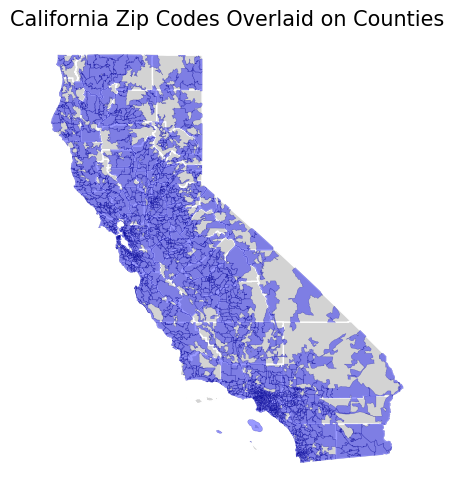

In [34]:
# Data Processing, Joining, and Cleaning
# Joining building code zones with zip codes
zip_code_to_bcz['Zip Code'] = zip_code_to_bcz['Zip Code'].astype(str).str.zfill(5)
cal_geo_data_gdf = cal_geo_data_gdf.merge(zip_code_to_bcz, left_on= 'ZCTA5CE20', right_on= 'Zip Code') 

# Data conversion requires inputting the FCZ values, which are set to county level not zip code
# Filtered list of California counties to merge with the GeoDataFrame
county_gdf = gpd.read_file('/Users/neil.stein/Documents/General Data Storage/cb_2024_us_all_500k/cb_2024_us_county_500k.zip')
ca_county_gdf = county_gdf[county_gdf['STATE_NAME'] == 'California']
ca_county_gdf = ca_county_gdf.to_crs(cal_geo_data_gdf.crs)

# Spatial join process to crosswalk the county-level FCZ values to the zip code level
ca_zip_centroids = cal_geo_data_gdf.copy()
ca_zip_centroids['geometry'] = ca_zip_centroids.geometry.centroid

ca_spatial_crosswalk = gpd.sjoin(ca_zip_centroids, ca_county_gdf[['NAME', 'geometry']], how= 'left', predicate= 'within')
cal_geo_data_gdf = cal_geo_data_gdf.merge(ca_spatial_crosswalk[['ZCTA5CE20', 'NAME']],on= 'ZCTA5CE20', how= 'left')
cal_geo_data_gdf.rename(columns={'NAME': 'County_Name'}, inplace=True)

# missing county names below, coastal region association issues hardcoded with a manual fix
manual_fix = {'93042': 'Ventura', '90742': 'Orange', '90743': 'Orange', '92155': 'San Diego', '92661': 'Orange'}
cal_geo_data_gdf['County_Name'] = cal_geo_data_gdf['County_Name'].fillna(cal_geo_data_gdf['ZCTA5CE20'].map(manual_fix))

# Map to check data quality and spatial join accuracy
fig, ax = plt.subplots(figsize=(5, 6))
ca_county_gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=1)
cal_geo_data_gdf.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue', linewidth=0.3)
ax.set_title("California Zip Codes Overlaid on Counties", fontsize=15)
ax.set_axis_off()
plt.show()

In [39]:
# FCZ value mapping to the GeoDataFrame
# cleaning the FCZ mapping data from the easy to read format for viewers to a data analysis-ready format
fcz_df = fcz_mapping.copy()

fcz_df = fcz_df.iloc[:, 1:].copy()
fcz_df.columns = fcz_df.iloc[0]
fcz_df = fcz_df.iloc[1:].reset_index(drop= True)

# Splitting the FCZ string into the number and the zone name
fcz_df.columns = fcz_df.columns.astype(str).str.strip()
fcz_df[['Planning Areas', 'CEUS Participant']] = fcz_df[['Planning Areas', 'CEUS Participant']].ffill()

fcz_components = fcz_df.iloc[:, 2].str.extract(r'(\d+)[.-]\s*(.*)')
fcz_df['FCZ Number'] = fcz_components[0]
fcz_df['Forecast Zone Name'] = fcz_components[1]
fcz_df.set_index('FCZ Number', inplace=True)
#print(fcz_df.head(5))

# Expanding the county list into the FCZ mapping dataframe
fcz_df.columns = fcz_df.columns.astype(str).str.strip()
county_col_name = fcz_df.columns[-1] 

# Based on the first print results there are some cleaning steps needed
fcz_df['Counties within Each Forecast Zones'] = (
    fcz_df['Counties within Each Forecast Zones']
    .str.replace(r'.*LA.*County.*', 'Los Angeles', regex=True, case=False) 
    .str.replace(r'partial:\s*', '', regex=True, case=False)               
    .str.replace(r'(Obispo)\s+(Santa)', r'\1, \2', regex=True)           
    .str.strip()
)

# Exploding the county data
fcz_expanded_df = fcz_df.assign(
    **{'Counties within Each Forecast Zones': fcz_df['Counties within Each Forecast Zones'].str.split(',')}
).explode('Counties within Each Forecast Zones')

fcz_expanded_df['Counties within Each Forecast Zones'] = fcz_expanded_df['Counties within Each Forecast Zones'].str.strip()
fcz_expanded_df = fcz_expanded_df[fcz_expanded_df['Counties within Each Forecast Zones'].astype(bool)]
fcz_expanded_df.set_index('Counties within Each Forecast Zones', inplace=True)

# Cleanup steps
fcz_expanded_df['FCZ Number'] = fcz_expanded_df['Forecast Zones (FCZ)'].str.extract(r'(\d+)[.-]')
fcz_expanded_df = fcz_expanded_df.dropna(subset=['FCZ Number'])

#print(fcz_expanded_df.index.name)
#print(fcz_expanded_df.head())

In [40]:
# Bringing the expanded FCZ mapping back to the geospatial data
# Aggregate FCZ Numbers into comma-separated strings per county
fcz_by_county = fcz_expanded_df.groupby('Counties within Each Forecast Zones')['FCZ Number'].apply(
    lambda x: ', '.join(x.astype(str).unique())
).reset_index()

# Add other attributes (Planning Areas, etc.) to the mapping
fcz_attributes = fcz_expanded_df.groupby('Counties within Each Forecast Zones')[
    ['Planning Areas', 'CEUS Participant']
].first().reset_index()

fcz_final_map = fcz_by_county.merge(fcz_attributes, on='Counties within Each Forecast Zones')

# Create the new variable for the County GeoDataFrame with attributes
ca_county_with_fcz_gdf = ca_county_gdf.merge(
    fcz_final_map,
    left_on='NAME',
    right_on='Counties within Each Forecast Zones',
    how='left'
)

# Map the attributes down to the Zip Code level
cal_geo_data_gdf = cal_geo_data_gdf.merge(
    ca_county_with_fcz_gdf[['NAME', 'FCZ Number', 'Planning Areas', 'CEUS Participant']],
    left_on='County_Name',
    right_on='NAME',
    how='left'
)

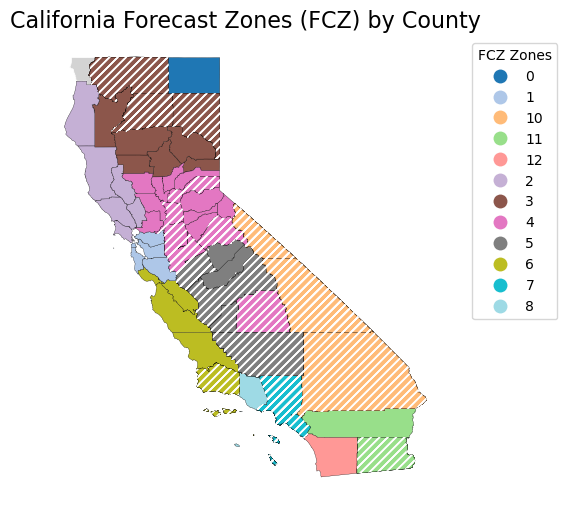

In [ ]:
# Simple visual check of the FCZ mapping results
# Counties with multiple zones (e.g., "12, 13") will be colored by the first ID
ca_county_with_fcz_gdf['Primary_FCZ'] = ca_county_with_fcz_gdf['FCZ Number'].str.split(',').str[0]

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(6, 6))

# 3. Plot the base Counties (Light grey for NaNs)
ca_county_with_fcz_gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

# 4. Plot the FCZ Zones
# We use 'Primary_FCZ' for the categorical color map
ca_county_with_fcz_gdf.dropna(subset=['Primary_FCZ']).plot(
    column='Primary_FCZ',
    ax=ax,
    legend=True,
    categorical=True,
    cmap='tab20', # High-contrast colormap for 20+ zones
    edgecolor='black',
    linewidth=0.2,
    legend_kwds={'title': "FCZ Zones", 'loc': 'upper right', 'bbox_to_anchor': (1.3, 1)}
)

# 5. Visual Cue for Multi-Zone Counties: Add a 'Stripe' effect using hatching
# This selects any row where a comma exists (indicating multiple zones)
multi_zone_mask = ca_county_with_fcz_gdf['FCZ Number'].str.contains(',', na=False)
ca_county_with_fcz_gdf[multi_zone_mask].plot(
    ax=ax,
    facecolor="none",
    hatch='////',
    edgecolor='white',
    linewidth=0
)

# Final formatting
ax.set_title("California Forecast Zones (FCZ) by County", fontsize=16)
ax.set_axis_off()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: /vsizip/Data Sources/ForecastingClimateZones_CEC_2015_6353131256179142586.zip/Forecasting_Climate_Zones.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


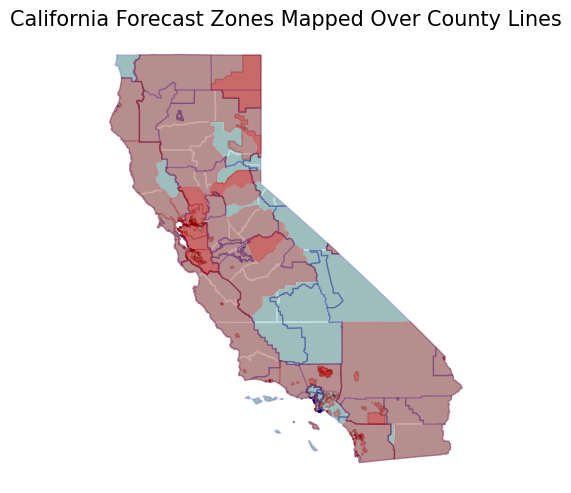

In [57]:
# Importing new data - California Energy Data from State of California departments (Emergency Services, Energy Commission, etc.)
cal_energy_forecast_zones_gdf = gpd.read_file('Data Sources/ForecastingClimateZones_CEC_2015_6353131256179142586.zip')
cal_energy_forecast_zones_gdf = cal_energy_forecast_zones_gdf.to_crs(ca_county_gdf.crs)

elec_load_gdf = gpd.read_file('Data Sources/ElectricLoadServingEntities_Other.zip')
elec_load_gdf = elec_load_gdf.to_crs(ca_county_gdf.crs)

fig, ax = plt.subplots(figsize=(5, 6))
ca_county_gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=1)
cal_energy_forecast_zones_gdf.plot(ax=ax, color= 'teal', alpha= 0.25, edgecolor='darkblue', linewidth= 1)
elec_load_gdf.plot(ax=ax, color= 'red', alpha= 0.25, edgecolor='darkred', linewidth= 1)
ax.set_title("California Forecast Zones Mapped Over County Lines", fontsize=15)
ax.set_axis_off()
plt.show()

In [43]:
# Associating the FCZ values with the zip code level data for further analysis
# First, correcting the BCZ to FCZ mapping dataframe
bcz_to_fcz_df = bcz_to_fcz_mapping.copy()

bcz_to_fcz_df = bcz_to_fcz_df.iloc[:, 1:].copy()
bcz_to_fcz_df.columns = bcz_to_fcz_df.iloc[0]
bcz_to_fcz_df = bcz_to_fcz_df.iloc[1:].reset_index(drop= True)

In [ ]:
# Importing GeoTIFF data to lay the foundation for a Dyasmetric Mapping Exercise
